Implementaion for svm(Features Sample_id+TF_IDF+SVD)

In [1]:
import os, joblib
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
#from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# ------------ config ------------
TRAIN = "train.csv"
TEST = "test.csv"
USE_SAMPLE_ID = True
LOG_TRANSFORM = True
# Ensure variable names match the rest of the notebook
TFIDF_MAX_FEATURES = 5000
SVD_COMPONENTS = 100
RANDOM_STATE = 42


In [3]:
# 1) Load data
train_path = "train.csv"
test_path = "test.csv"
df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [4]:
# feature selection 
text_col = "catalog_content"
id_col = "sample_id"
target_col = "price"

In [5]:
#converting the categorial features to numerical features

def make_text_features(series):
    s = series.fillna("").astype(str)
    desc_len = s.str.len()
    word_count = s.str.split().map(len)
    avg_word_len = (desc_len / (word_count.replace(0,1))).fillna(0)
    num_digits = s.str.count(r"\d")
    num_commas = s.str.count(",")
    return pd.DataFrame({
        "desc_len": desc_len,
        "word_count": word_count,
        "avg_word_len": avg_word_len,
        "num_digits": num_digits,
        "num_commas": num_commas
    })

X_num_features = make_text_features(df[text_col])
X_num_features_test = make_text_features(test_df[text_col])

In [6]:
if USE_SAMPLE_ID:
    X_num_features["sample_id"] = df[id_col].astype(float).values
    X_num_features_test["sample_id"] = test_df[id_col].astype(float).values

# target (log-transform)
y = df[target_col].values
if LOG_TRANSFORM:
    # avoid log(0)
    y_trans = np.log1p(y)
else:
    y_trans = y

In [7]:
# split train/val
X_text = df[text_col].reset_index(drop=True)
X_text_test = test_df[text_col].reset_index(drop=True)

X_train_text, X_val_text, X_train_num, X_val_num, y_train, y_val = train_test_split(
    X_text, X_num_features, y_trans, test_size=0.2, random_state=RANDOM_STATE
)


In [8]:
# 4) Build text pipeline: TF-IDF -> SVD
tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=(1,2), stop_words='english')
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
text_pipeline = Pipeline([("tfidf", tfidf), ("svd", svd)])


In [9]:
num_pipeline = Pipeline([("scaler", StandardScaler())])

In [10]:
# 4) Build the text + numeric feature processing
text_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, stop_words="english")),
    ("svd", TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE))
])

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Combine text and numeric pipelines
preprocessor = ColumnTransformer([
    ("text", text_pipeline, "text"),
    ("num", num_pipeline, [c for c in X_train_num.columns])
], remainder="drop", sparse_threshold=0)

# Prepare combined input (text + numeric together)
def combine_input(text_series, num_df):
    df_combined = pd.DataFrame({"text": text_series.reset_index(drop=True)})
    for col in num_df.columns:
        df_combined[col] = num_df[col].reset_index(drop=True)
    return df_combined

X_train_combined = combine_input(X_train_text, X_train_num)
X_val_combined = combine_input(X_val_text, X_val_num)
X_test_combined = combine_input(X_text_test, X_num_features_test)


In [11]:
# 5) Build the SVR pipeline
svr = SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.2)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("svr", svr)
])

In [12]:
# 6) Train the model
print("Training SVM model... ⏳")
model.fit(X_train_combined, y_train)
print("✅ Model training complete!")

Training SVM model... ⏳
✅ Model training complete!
✅ Model training complete!


In [13]:
#Validate
y_val_pred = model.predict(X_val_combined)
if LOG_TRANSFORM:
    y_val_pred = np.expm1(y_val_pred)
    y_val_true = np.expm1(y_val)
else:
    y_val_true = y_val


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute metrics
#rmse = mean_squared_error(y_val_true, y_val_pred, squared=False)  # correct usage
mae = mean_absolute_error(y_val_true, y_val_pred)
r2 = r2_score(y_val_true, y_val_pred)

#print(f"📊 Validation RMSE: {rmse:.3f}")
print(f"📊 Validation MAE: {mae:.3f}")
print(f"📈 Validation R²: {r2:.3f}")


📊 Validation MAE: 13.650
📈 Validation R²: 0.157


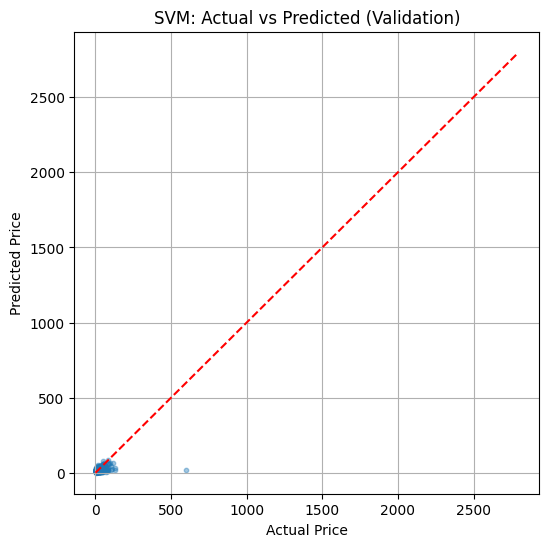

In [17]:
# 8) Plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_val_true[:500], y_val_pred[:500], alpha=0.4, s=10)
plt.plot([y_val_true.min(), y_val_true.max()], [y_val_true.min(), y_val_true.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVM: Actual vs Predicted (Validation)")
plt.grid(True)
plt.show()


In [18]:
# 9) Predict for test.csv
y_test_pred = model.predict(X_test_combined)
if LOG_TRANSFORM:
    y_test_pred = np.expm1(y_test_pred)

test_df["predicted_price"] = y_test_pred
test_df.to_csv("predicted_prices_svm.csv", index=False)
print("💾 Saved predictions to predicted_prices_svm.csv")


💾 Saved predictions to predicted_prices_svm.csv


In [19]:
 #Save model for reuse
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/svm_price_model.joblib")
print("💾 Model saved to models/svm_price_model.joblib")

💾 Model saved to models/svm_price_model.joblib
